# 03 - Visualization Storyboard

**Use case:** Cancer-wise Drug Intelligence  
**Input:** `data/processed/trials_processed.csv`, `data/processed/drug_phase_map.csv`, `data/processed/cancer_hierarchy_final.json`, `data/processed/drug_combination_partners.json`  
**Goal:** Build stakeholder-facing visual analysis that becomes the blueprint for the website.

This notebook is Plotly-first for reliability in Jupyter, but it is intentionally styled and structured like a product dashboard rather than a default analytics notebook.

## What This Notebook Covers

1. Executive KPI snapshot  
2. Phase-wise funnel and pipeline depth  
3. Sponsor pressure by phase  
4. Biomarker concentration by phase  
5. Leading asset landscape  
6. Recruitment distribution and status risk  
7. Geography concentration  
8. Combination partner drill-down  
9. Presentation-ready insight table

In [69]:
import ast
import json
import re
from pathlib import Path

import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 160)

PHASE_ORDER = ["Early Phase 1", "Phase 1", "Phase 2", "Phase 3", "Phase 4"]
GENERIC_DROPDOWN_TERMS = {
    "stoma",
    "stage ii",
    "hepatocellular",
    "malignant",
    "adenocarcinoma",
    "cell carcinoma",
    "solid tumor",
    "solid tumour",
}

PALETTE = {
    "ink": "#111827",
    "muted": "#6b7280",
    "sand": "#f7f1e8",
    "paper": "#fcfaf6",
    "teal": "#0f766e",
    "cyan": "#155e75",
    "blue": "#1d4ed8",
    "amber": "#b45309",
    "rose": "#be123c",
    "violet": "#6d28d9",
    "olive": "#4d7c0f",
}

PLOTLY_SEQ = [
    PALETTE["teal"],
    PALETTE["cyan"],
    PALETTE["blue"],
    PALETTE["amber"],
    PALETTE["rose"],
    PALETTE["violet"],
    PALETTE["olive"],
]

COMMON_LAYOUT = dict(
    paper_bgcolor=PALETTE["paper"],
    plot_bgcolor=PALETTE["paper"],
    font=dict(family="Georgia, Times New Roman, serif", color=PALETTE["ink"], size=13),
    title_font=dict(size=24, color=PALETTE["ink"]),
    legend=dict(bgcolor="rgba(0,0,0,0)", orientation="h", yanchor="bottom", y=1.02, xanchor="left", x=0),
    margin=dict(l=60, r=40, t=90, b=60),
)

px.defaults.template = "plotly_white"
px.defaults.color_discrete_sequence = PLOTLY_SEQ

print("Imports OK")

Imports OK


In [70]:
project_root = Path.cwd()
processed_dir = project_root / "data" / "processed"

required_files = {
    "trials_processed": processed_dir / "trials_processed.csv",
    "drug_phase_map": processed_dir / "drug_phase_map.csv",
    "cancer_hierarchy": processed_dir / "cancer_hierarchy_final.json",
    "drug_partners": processed_dir / "drug_combination_partners.json",
}

missing = [name for name, path in required_files.items() if not path.exists()]
if missing:
    raise FileNotFoundError(
        "Missing processed file(s): " + ", ".join(missing) + "\n"
        + f"Expected them inside: {processed_dir}"
    )

df = pd.read_csv(required_files["trials_processed"], low_memory=False)
df_drug_phase = pd.read_csv(required_files["drug_phase_map"], low_memory=False)

with open(required_files["cancer_hierarchy"], "r", encoding="utf-8") as f:
    cancer_hierarchy = json.load(f)

with open(required_files["drug_partners"], "r", encoding="utf-8") as f:
    drug_partners = json.load(f)

print(f"Trials processed      : {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Drug-phase map        : {df_drug_phase.shape[0]:,} rows")
print(f"Cancer hierarchy keys : {len(cancer_hierarchy):,}")
print(f"Drug partner entries  : {len(drug_partners):,}")

Trials processed      : 123,526 rows x 69 columns
Drug-phase map        : 144,892 rows
Cancer hierarchy keys : 75
Drug partner entries  : 19,409


In [71]:
PIPE_COLS = [
    "conditions",
    "countries",
    "all_drugs_normalized",
    "biomarkers_all",
    "mutations_all",
    "ner_diseases_title",
    "ner_diseases_eligibility",
    "patient_profile_flags",
    "primary_outcomes_standardized",
]

DATE_COLS = [
    "start_date",
    "primary_completion_date",
    "completion_date",
    "first_posted_date",
]

def parse_pipe(value):
    if pd.isna(value):
        return []
    value = str(value).strip()
    if not value or value.lower() == "nan":
        return []
    return [item.strip() for item in value.split("|") if item.strip()]

def parse_phase_buckets(value):
    if isinstance(value, list):
        return value
    if pd.isna(value):
        return []
    value = str(value).strip()
    if not value or value.lower() == "nan":
        return []
    try:
        parsed = ast.literal_eval(value)
        if isinstance(parsed, list):
            return parsed
    except Exception:
        pass
    return [value]

for col in PIPE_COLS:
    if col in df.columns:
        df[col + "_list"] = df[col].map(parse_pipe)

for col in DATE_COLS:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")

df["phase_buckets_list"] = df["phase_buckets"].map(parse_phase_buckets)

clean_cancers = {
    cancer: payload
    for cancer, payload in cancer_hierarchy.items()
    if cancer.strip().lower() not in GENERIC_DROPDOWN_TERMS
}

def get_cancer_terms(selected_cancer):
    payload = clean_cancers[selected_cancer]
    subtype_terms = [item["condition"] for item in payload.get("subtypes", [])]
    return [selected_cancer] + subtype_terms

def build_cancer_mask(frame, selected_cancer):
    terms = get_cancer_terms(selected_cancer)
    pattern = r"(?i)(?:" + "|".join(re.escape(t) for t in terms if str(t).strip()) + r")"
    text_cols = [
        "conditions",
        "brief_title",
        "official_title",
        "ner_diseases_title",
        "ner_diseases_eligibility",
    ]
    mask = pd.Series(False, index=frame.index)
    for col in text_cols:
        if col in frame.columns:
            mask = mask | frame[col].fillna("").astype(str).str.contains(pattern, regex=True)
    return mask, terms

def explode_pipe_counts(series):
    values = []
    for val in series:
        values.extend(parse_pipe(val))
    if not values:
        return pd.Series(dtype=int)
    return pd.Series(values).value_counts()

def phase_summary_for(frame_trials, frame_drug_phase):
    interventional = frame_trials[frame_trials["study_type"] == "INTERVENTIONAL"].copy()
    rows = []
    for phase in PHASE_ORDER:
        phase_trials = interventional[interventional["phase_buckets_list"].map(lambda vals: phase in vals)]
        phase_drugs = frame_drug_phase[
            (frame_drug_phase["study_type"] == "INTERVENTIONAL")
            & (frame_drug_phase["phase_bucket"] == phase)
        ]
        rows.append({
            "phase": phase,
            "unique_trials": int(phase_trials["nct_id"].nunique()),
            "distinct_drugs": int(phase_drugs["drug_name"].nunique()),
            "total_enrollment": int(phase_trials["enrollment_count"].fillna(0).sum()),
        })
    return pd.DataFrame(rows)

def pretty_layout(fig, title, subtitle=None, height=620):
    fig.update_layout(**COMMON_LAYOUT)
    fig.update_layout(height=height, title=dict(text=title, x=0.02))
    if subtitle:
        fig.add_annotation(
            text=subtitle,
            xref="paper",
            yref="paper",
            x=0.0,
            y=1.09,
            showarrow=False,
            font=dict(size=12, color=PALETTE["muted"]),
            align="left",
        )
    return fig

print(f"Usable cancers for visual layer: {len(clean_cancers):,}")
pd.DataFrame({"cancer": list(clean_cancers.keys())}).head(12)

Usable cancers for visual layer: 75


,cancer
0,Breast Cancer
1,Prostate Cancer
2,Colorectal Cancer
3,Lung Cancer
4,Multiple Myeloma
5,Lymphoma
6,Ovarian Cancer
7,Pancreatic Cancer
8,Hepatocellular Carcinoma
9,Gastric Cancer


In [72]:
# Controls
SELECTED_CANCER = "Breast Cancer"
SELECTED_DRUG = None
MIN_DRUG_TRIALS = 3
TOP_N_DRUGS = 15
TOP_N_BIOMARKERS = 12
TOP_N_COUNTRIES = 12

assert SELECTED_CANCER in clean_cancers, (
    f"`{SELECTED_CANCER}` not found in cleaned cancer hierarchy. Try one of: {list(clean_cancers)[:10]}"
)

mask, matched_terms = build_cancer_mask(df, SELECTED_CANCER)
df_cancer = df[mask].copy()
df_cancer_interventional = df_cancer[df_cancer["study_type"] == "INTERVENTIONAL"].copy()
cancer_drug_phase = df_drug_phase[df_drug_phase["nct_id"].isin(df_cancer["nct_id"])].copy()

summary = {
    "trials": int(df_cancer["nct_id"].nunique()),
    "interventional_trials": int(df_cancer_interventional["nct_id"].nunique()),
    "drugs": int(cancer_drug_phase["drug_name"].nunique()),
    "patients": int(df_cancer_interventional["enrollment_count"].fillna(0).sum()),
    "countries": int(explode_pipe_counts(df_cancer["countries"]).shape[0]),
}

print(f"Selected cancer         : {SELECTED_CANCER}")
print(f"Matched search terms    : {len(matched_terms):,}")
print(f"Total trials            : {summary['trials']:,}")
print(f"Interventional trials   : {summary['interventional_trials']:,}")
print(f"Distinct drugs          : {summary['drugs']:,}")
print(f"Targeted patients       : {summary['patients']:,}")
print(f"Countries represented   : {summary['countries']:,}")

Selected cancer         : Breast Cancer
Matched search terms    : 31
Total trials            : 16,610
Interventional trials   : 13,318
Distinct drugs          : 5,361
Targeted patients       : 12,058,146
Countries represented   : 120


## Executive Snapshot

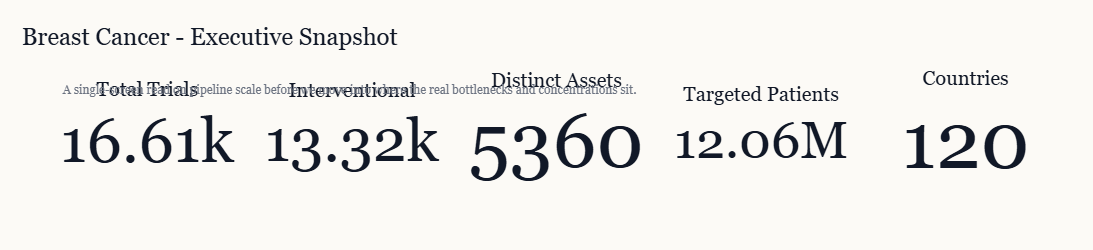

In [73]:
fig_kpi = make_subplots(
    rows=1,
    cols=5,
    specs=[[{"type": "indicator"}] * 5],
    horizontal_spacing=0.03,
)

fig_kpi.add_trace(go.Indicator(mode="number", value=summary["trials"], title={"text": "Total Trials"}), row=1, col=1)
fig_kpi.add_trace(go.Indicator(mode="number", value=summary["interventional_trials"], title={"text": "Interventional"}), row=1, col=2)
fig_kpi.add_trace(go.Indicator(mode="number", value=summary["drugs"], title={"text": "Distinct Assets"}), row=1, col=3)
fig_kpi.add_trace(go.Indicator(mode="number", value=summary["patients"], title={"text": "Targeted Patients"}), row=1, col=4)
fig_kpi.add_trace(go.Indicator(mode="number", value=summary["countries"], title={"text": "Countries"}), row=1, col=5)

pretty_layout(
    fig_kpi,
    title=f"{SELECTED_CANCER} - Executive Snapshot",
    subtitle="A single-screen read on pipeline scale before we move into where the real bottlenecks and concentrations sit.",
    height=250,
)
fig_kpi.show()

## 1. Phase Funnel and Pipeline Depth

In [74]:
phase_summary = phase_summary_for(df_cancer, cancer_drug_phase)
phase_summary

,phase,unique_trials,distinct_drugs,total_enrollment
0,Early Phase 1,232,192,18532
1,Phase 1,2743,2263,215653
2,Phase 2,4744,2916,637736
3,Phase 3,1572,1048,1392901
4,Phase 4,346,282,570312


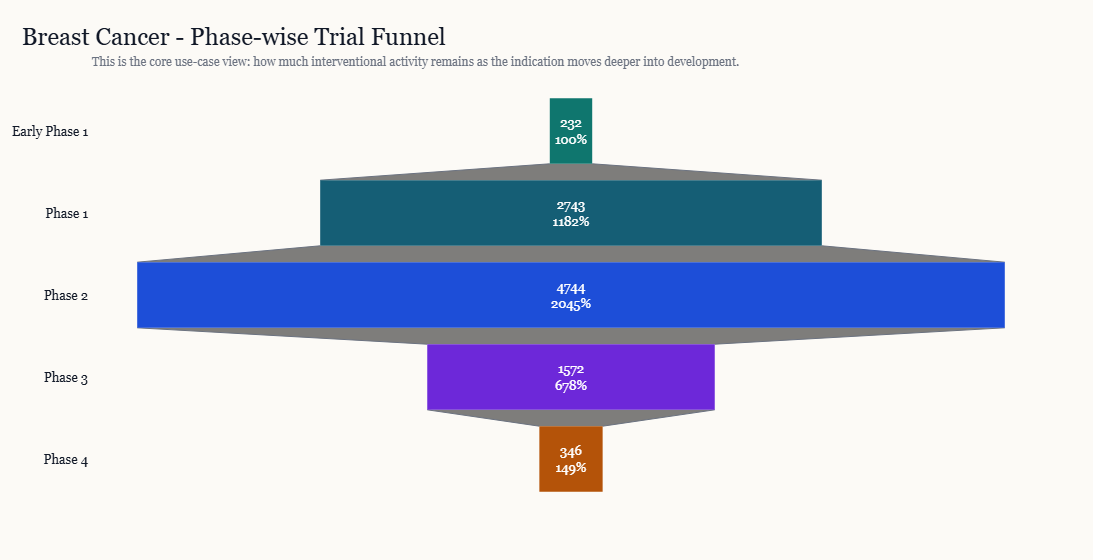

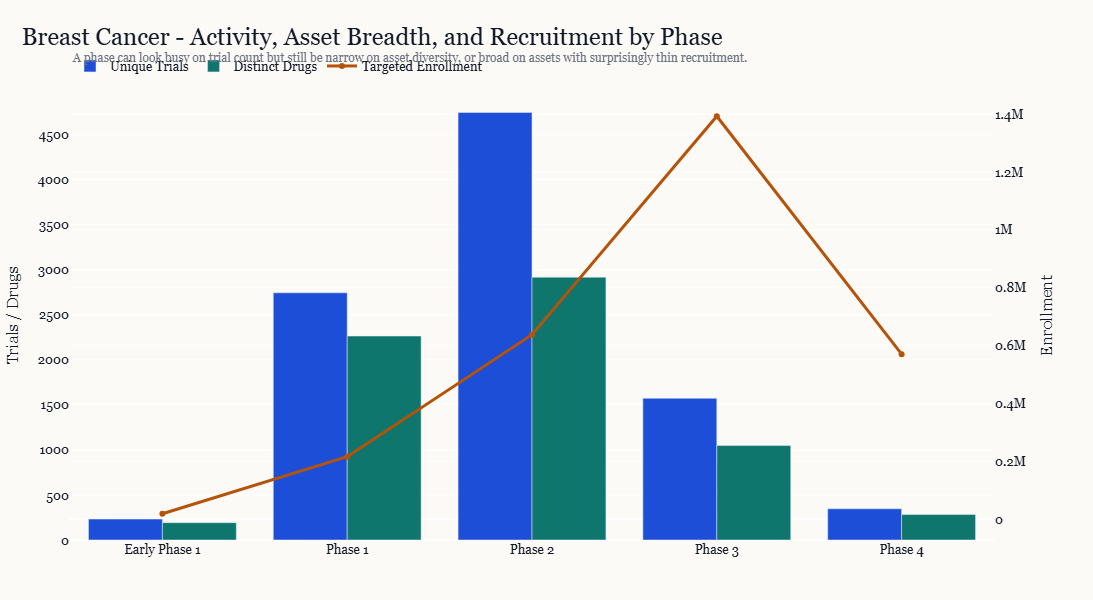

In [75]:
fig_funnel = go.Figure(
    go.Funnel(
        y=phase_summary["phase"],
        x=phase_summary["unique_trials"],
        textposition="inside",
        textinfo="value+percent initial",
        marker={"color": [PALETTE["teal"], PALETTE["cyan"], PALETTE["blue"], PALETTE["violet"], PALETTE["amber"]]},
        connector={"line": {"color": PALETTE["muted"], "width": 1}},
    )
)
pretty_layout(
    fig_funnel,
    title=f"{SELECTED_CANCER} - Phase-wise Trial Funnel",
    subtitle="This is the core use-case view: how much interventional activity remains as the indication moves deeper into development.",
    height=560,
)
fig_funnel.show()

fig_phase_depth = make_subplots(specs=[[{"secondary_y": True}]])
fig_phase_depth.add_bar(x=phase_summary["phase"], y=phase_summary["unique_trials"], name="Unique Trials", marker_color=PALETTE["blue"], secondary_y=False)
fig_phase_depth.add_bar(x=phase_summary["phase"], y=phase_summary["distinct_drugs"], name="Distinct Drugs", marker_color=PALETTE["teal"], secondary_y=False)
fig_phase_depth.add_trace(go.Scatter(x=phase_summary["phase"], y=phase_summary["total_enrollment"], name="Targeted Enrollment", mode="lines+markers", line=dict(color=PALETTE["amber"], width=3)), secondary_y=True)
pretty_layout(
    fig_phase_depth,
    title=f"{SELECTED_CANCER} - Activity, Asset Breadth, and Recruitment by Phase",
    subtitle="A phase can look busy on trial count but still be narrow on asset diversity, or broad on assets with surprisingly thin recruitment.",
    height=600,
)
fig_phase_depth.update_yaxes(title_text="Trials / Drugs", secondary_y=False)
fig_phase_depth.update_yaxes(title_text="Enrollment", secondary_y=True)
fig_phase_depth.show()

## 2. Sponsor Pressure by Phase

This heatmap usually lands well with stakeholders because it immediately shows whether the deeper pipeline is being carried by industry or fragmented across other sponsor classes.

In [76]:
sponsor_phase = (
    df_cancer_interventional
    .explode("phase_buckets_list")
    .dropna(subset=["phase_buckets_list"])
    .groupby(["lead_sponsor_class", "phase_buckets_list"])["nct_id"]
    .nunique()
    .reset_index(name="unique_trials")
)
sponsor_phase = sponsor_phase[sponsor_phase["phase_buckets_list"].isin(PHASE_ORDER)]
sponsor_pivot = sponsor_phase.pivot(index="lead_sponsor_class", columns="phase_buckets_list", values="unique_trials").fillna(0)
sponsor_pivot = sponsor_pivot.reindex(columns=PHASE_ORDER)
sponsor_pivot

phase_buckets_list,Early Phase 1,Phase 1,Phase 2,Phase 3,Phase 4
lead_sponsor_class,,,,,
FED,0.0,4.0,1.0,1.0,1.0
INDIV,0.0,1.0,3.0,0.0,0.0
INDUSTRY,18.0,1444.0,1227.0,564.0,76.0
NETWORK,0.0,27.0,98.0,108.0,0.0
NIH,3.0,134.0,153.0,25.0,0.0
OTHER,208.0,1114.0,3158.0,839.0,265.0
OTHER_GOV,3.0,19.0,103.0,34.0,4.0
UNKNOWN,0.0,0.0,1.0,1.0,0.0


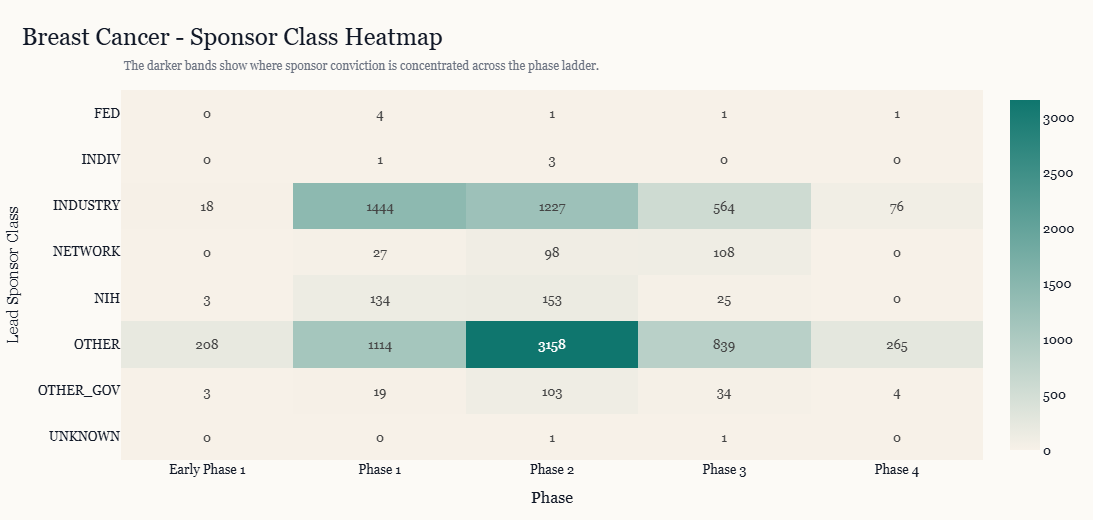

In [77]:
fig_sponsor_heat = px.imshow(
    sponsor_pivot,
    text_auto=True,
    aspect="auto",
    color_continuous_scale=[PALETTE["sand"], PALETTE["teal"]],
)
pretty_layout(
    fig_sponsor_heat,
    title=f"{SELECTED_CANCER} - Sponsor Class Heatmap",
    subtitle="The darker bands show where sponsor conviction is concentrated across the phase ladder.",
    height=520,
)
fig_sponsor_heat.update_xaxes(title_text="Phase")
fig_sponsor_heat.update_yaxes(title_text="Lead Sponsor Class")
fig_sponsor_heat.show()

## 3. Molecular Pressure by Phase

Rather than just listing biomarkers, this view shows where the molecular story is concentrated in the development funnel.

In [78]:
biomarker_phase_rows = []
for row in df_cancer_interventional.itertuples():
    biomarkers = getattr(row, "biomarkers_all_list", [])
    phases = getattr(row, "phase_buckets_list", [])
    if not biomarkers or not phases:
        continue
    for biomarker in biomarkers:
        for phase in phases:
            if phase in PHASE_ORDER:
                biomarker_phase_rows.append({"phase": phase, "biomarker": biomarker, "nct_id": row.nct_id})

df_biomarker_phase = pd.DataFrame(biomarker_phase_rows)
top_biomarkers = df_biomarker_phase.groupby("biomarker")["nct_id"].nunique().sort_values(ascending=False).head(TOP_N_BIOMARKERS).index.tolist()
df_biomarker_phase = df_biomarker_phase[df_biomarker_phase["biomarker"].isin(top_biomarkers)]
biomarker_phase_pivot = (
    df_biomarker_phase.groupby(["biomarker", "phase"])["nct_id"]
    .nunique()
    .reset_index(name="unique_trials")
    .pivot(index="biomarker", columns="phase", values="unique_trials")
    .fillna(0)
    .reindex(columns=PHASE_ORDER)
)
biomarker_phase_pivot

phase,Early Phase 1,Phase 1,Phase 2,Phase 3,Phase 4
biomarker,,,,,
ALK,2.0,75.0,79.0,6.0,0.0
BRCA,5.0,145.0,236.0,66.0,6.0
CDK4/6,3.0,202.0,313.0,109.0,14.0
EGFR,9.0,182.0,224.0,28.0,13.0
ER,16.0,117.0,357.0,103.0,8.0
HER2,71.0,1217.0,2565.0,710.0,83.0
MET,12.0,154.0,255.0,78.0,5.0
PD-L1,17.0,282.0,437.0,59.0,4.0
PIK3CA,2.0,59.0,67.0,26.0,1.0


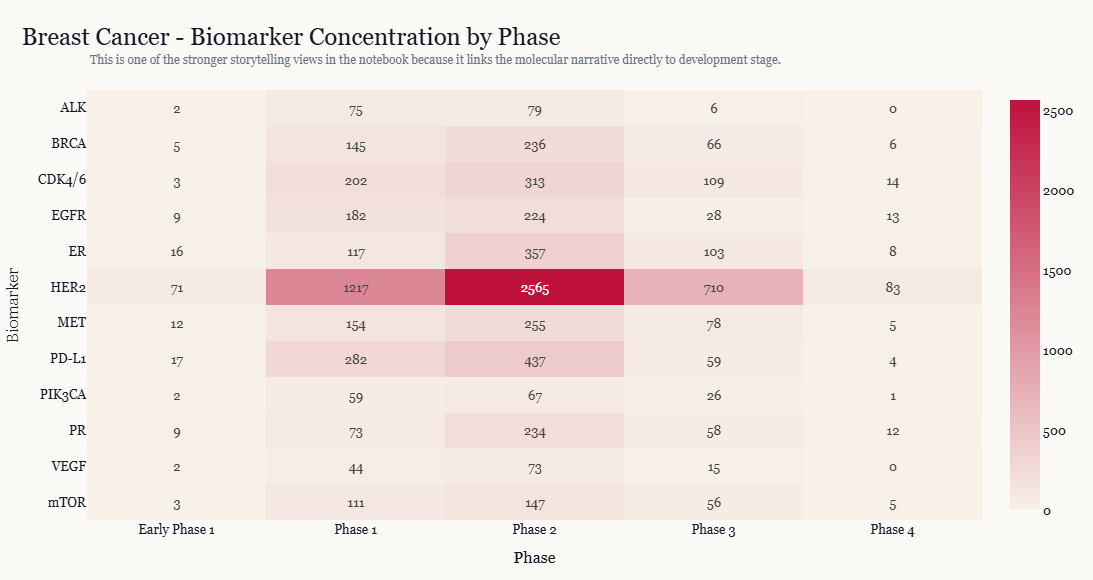

In [79]:
fig_biomarker_heat = px.imshow(
    biomarker_phase_pivot,
    text_auto=True,
    aspect="auto",
    color_continuous_scale=[PALETTE["sand"], PALETTE["rose"]],
)
pretty_layout(
    fig_biomarker_heat,
    title=f"{SELECTED_CANCER} - Biomarker Concentration by Phase",
    subtitle="This is one of the stronger storytelling views in the notebook because it links the molecular narrative directly to development stage.",
    height=580,
)
fig_biomarker_heat.update_xaxes(title_text="Phase")
fig_biomarker_heat.update_yaxes(title_text="Biomarker")
fig_biomarker_heat.show()

## 4. Leading Asset Landscape

This scatter is more presentation-worthy than a simple ranking bar because it shows trial intensity, phase coverage, and recruitment weight in one frame.

In [80]:
drug_landscape = (
    cancer_drug_phase[cancer_drug_phase["study_type"] == "INTERVENTIONAL"]
    .groupby("drug_name")
    .agg(unique_trials=("nct_id", "nunique"), phases_covered=("phase_bucket", "nunique"))
    .reset_index()
)
drug_enrollment = (
    df_cancer_interventional[["nct_id", "enrollment_count", "all_drugs_normalized_list"]]
    .explode("all_drugs_normalized_list")
    .dropna(subset=["all_drugs_normalized_list"])
    .groupby("all_drugs_normalized_list")["enrollment_count"]
    .sum()
    .reset_index()
    .rename(columns={"all_drugs_normalized_list": "drug_name", "enrollment_count": "total_enrollment"})
)
drug_landscape = drug_landscape.merge(drug_enrollment, on="drug_name", how="left").fillna({"total_enrollment": 0})
drug_landscape = drug_landscape[drug_landscape["unique_trials"] >= MIN_DRUG_TRIALS]
drug_landscape_top = drug_landscape.sort_values(["unique_trials", "phases_covered"], ascending=[False, False]).head(TOP_N_DRUGS)
drug_landscape_top

,drug_name,unique_trials,phases_covered,total_enrollment
3473,Paclitaxel,602,5,192755.0
1286,Cyclophosphamide,535,5,218817.0
1493,Docetaxel,452,5,161981.0
4651,Trastuzumab,401,5,94150.0
1072,Carboplatin,360,5,96970.0
1028,Capecitabine,349,5,94572.0
2016,Fulvestrant,327,5,65421.0
2743,Letrozole,304,5,154873.0
3683,Pertuzumab,176,5,60104.0
1837,Exemestane,176,4,132755.0


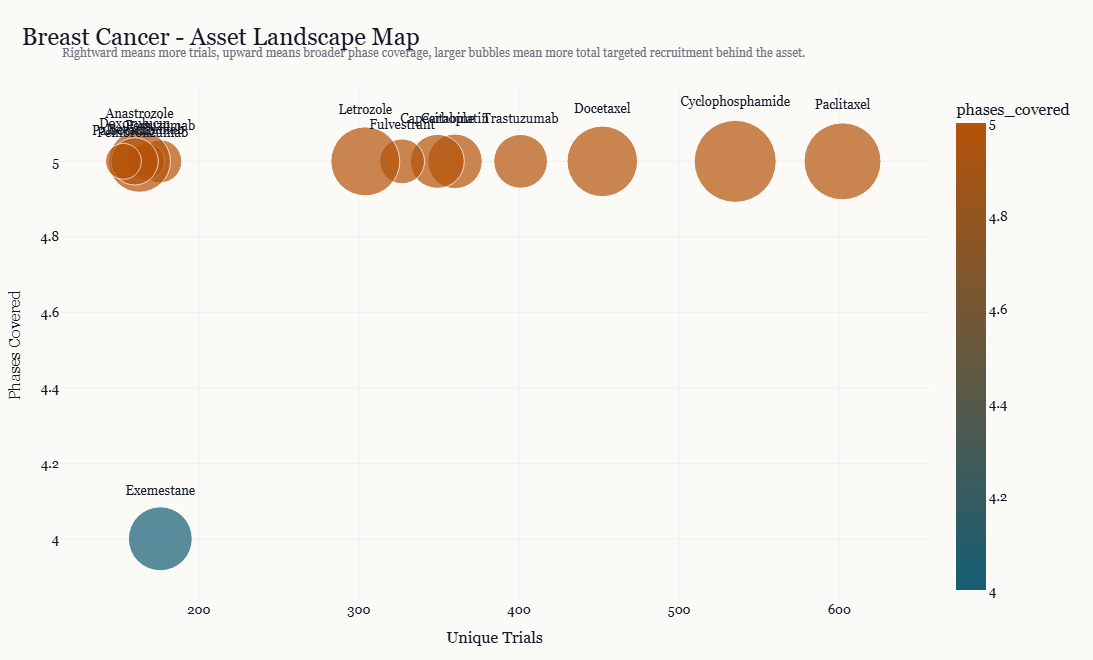

In [81]:
fig_drug_scatter = px.scatter(
    drug_landscape_top,
    x="unique_trials",
    y="phases_covered",
    size="total_enrollment",
    color="phases_covered",
    hover_name="drug_name",
    text="drug_name",
    size_max=58,
    color_continuous_scale=[PALETTE["cyan"], PALETTE["amber"]],
)
fig_drug_scatter.update_traces(textposition="top center")
pretty_layout(
    fig_drug_scatter,
    title=f"{SELECTED_CANCER} - Asset Landscape Map",
    subtitle="Rightward means more trials, upward means broader phase coverage, larger bubbles mean more total targeted recruitment behind the asset.",
    height=660,
)
fig_drug_scatter.update_xaxes(title_text="Unique Trials")
fig_drug_scatter.update_yaxes(title_text="Phases Covered")
fig_drug_scatter.show()

## 5. Recruitment and Risk Patterning

In [82]:
phase_enrollment_rows = []
for row in df_cancer_interventional.itertuples():
    phases = getattr(row, "phase_buckets_list", [])
    if not phases:
        continue
    for phase in phases:
        if phase in PHASE_ORDER:
            phase_enrollment_rows.append({
                "phase": phase,
                "enrollment_count": row.enrollment_count,
                "overall_status": row.overall_status,
            })

df_phase_enrollment = pd.DataFrame(phase_enrollment_rows)
df_phase_enrollment = df_phase_enrollment[df_phase_enrollment["enrollment_count"].notna()]
df_phase_enrollment["enrollment_count"] = df_phase_enrollment["enrollment_count"].clip(upper=df_phase_enrollment["enrollment_count"].quantile(0.99))
df_phase_enrollment.head()

,phase,enrollment_count,overall_status
0,Phase 2,20.0,UNKNOWN
1,Phase 3,647.0,COMPLETED
2,Phase 2,10.0,ACTIVE_NOT_RECRUITING
3,Phase 1,24.0,COMPLETED
4,Phase 2,0.0,WITHDRAWN


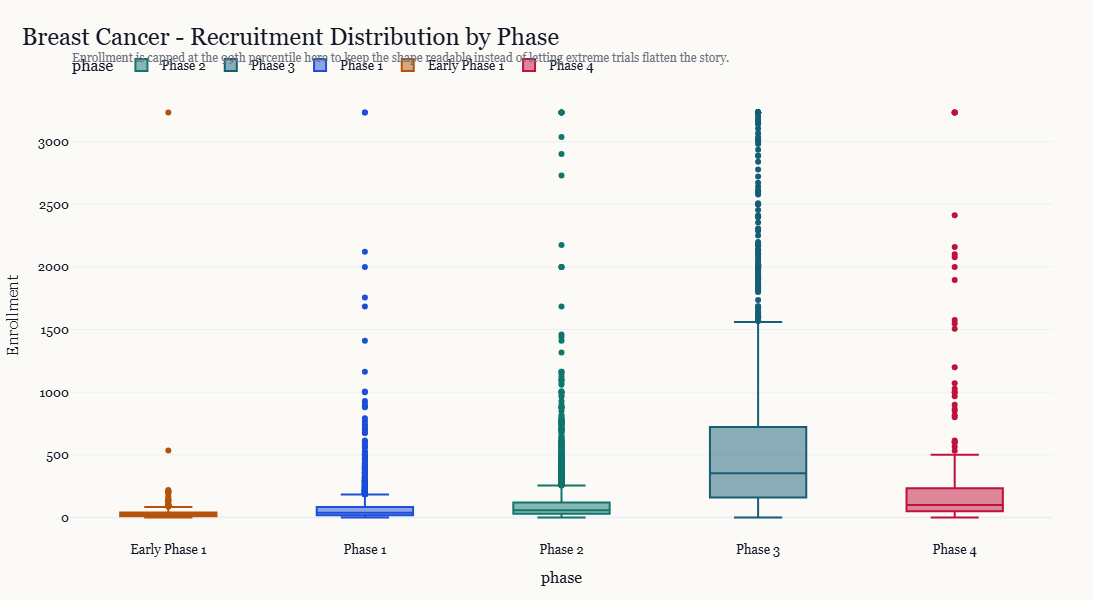

In [83]:
fig_enrollment_box = px.box(
    df_phase_enrollment,
    x="phase",
    y="enrollment_count",
    color="phase",
    points="outliers",
)
pretty_layout(
    fig_enrollment_box,
    title=f"{SELECTED_CANCER} - Recruitment Distribution by Phase",
    subtitle="Enrollment is capped at the 99th percentile here to keep the shape readable instead of letting extreme trials flatten the story.",
    height=600,
)
fig_enrollment_box.update_xaxes(categoryorder="array", categoryarray=PHASE_ORDER)
fig_enrollment_box.update_yaxes(title_text="Enrollment")
fig_enrollment_box.show()

In [84]:
risk_statuses = ["COMPLETED", "RECRUITING", "TERMINATED", "ACTIVE_NOT_RECRUITING", "NOT_YET_RECRUITING", "WITHDRAWN"]
phase_status = (
    df_cancer_interventional
    .explode("phase_buckets_list")
    .dropna(subset=["phase_buckets_list"])
    .groupby(["phase_buckets_list", "overall_status"])["nct_id"]
    .nunique()
    .reset_index(name="unique_trials")
)
phase_status = phase_status[
    phase_status["phase_buckets_list"].isin(PHASE_ORDER)
    & phase_status["overall_status"].isin(risk_statuses)
]
phase_status_pivot = phase_status.pivot(index="overall_status", columns="phase_buckets_list", values="unique_trials").fillna(0)
phase_status_pivot = phase_status_pivot.reindex(columns=PHASE_ORDER)
phase_status_pivot

phase_buckets_list,Early Phase 1,Phase 1,Phase 2,Phase 3,Phase 4
overall_status,,,,,
ACTIVE_NOT_RECRUITING,8,200,369,167,8
COMPLETED,112,1252,1895,735,162
NOT_YET_RECRUITING,10,89,253,73,26
RECRUITING,36,466,720,216,42
TERMINATED,19,383,665,111,23
WITHDRAWN,21,107,184,32,11


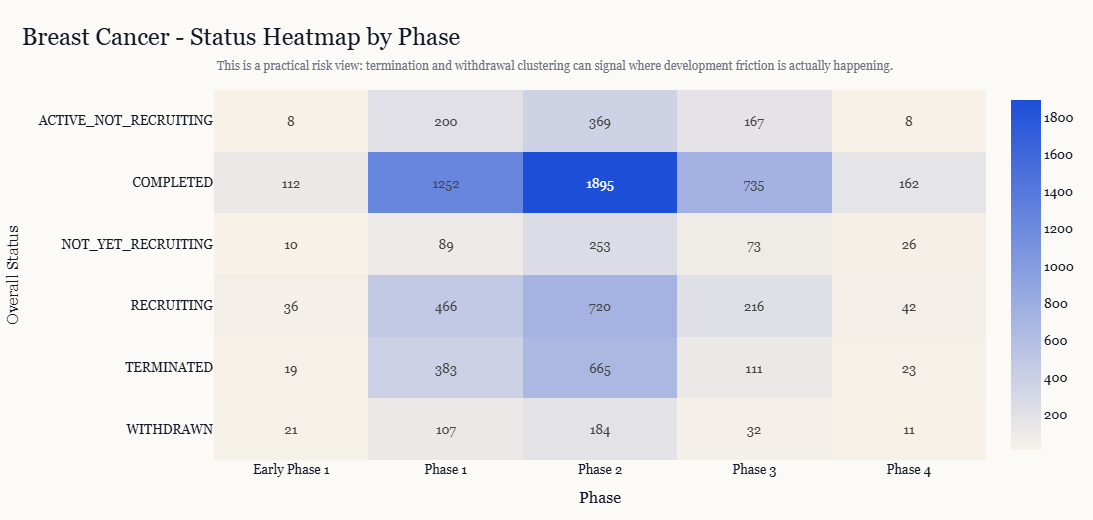

In [85]:
fig_status_heat = px.imshow(
    phase_status_pivot,
    text_auto=True,
    aspect="auto",
    color_continuous_scale=[PALETTE["sand"], PALETTE["blue"]],
)
pretty_layout(
    fig_status_heat,
    title=f"{SELECTED_CANCER} - Status Heatmap by Phase",
    subtitle="This is a practical risk view: termination and withdrawal clustering can signal where development friction is actually happening.",
    height=520,
)
fig_status_heat.update_xaxes(title_text="Phase")
fig_status_heat.update_yaxes(title_text="Overall Status")
fig_status_heat.show()

## 6. Geography and Market Footprint

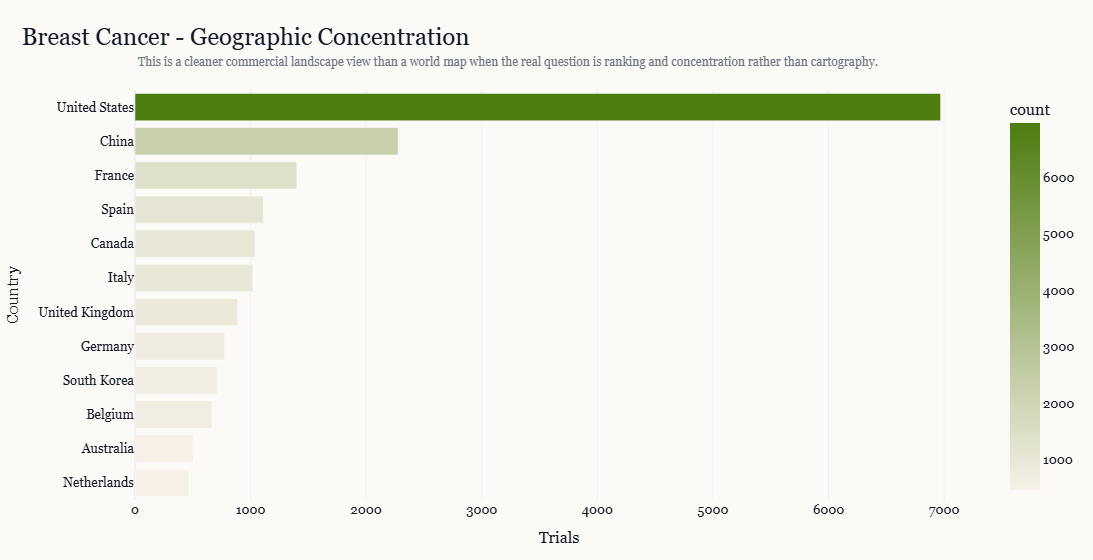

In [86]:
country_counts = explode_pipe_counts(df_cancer["countries"]).head(TOP_N_COUNTRIES)
fig_geo = px.bar(
    country_counts.reset_index(),
    x="count",
    y="index",
    orientation="h",
    color="count",
    color_continuous_scale=[PALETTE["sand"], PALETTE["olive"]],
)
pretty_layout(
    fig_geo,
    title=f"{SELECTED_CANCER} - Geographic Concentration",
    subtitle="This is a cleaner commercial landscape view than a world map when the real question is ranking and concentration rather than cartography.",
    height=560,
)
fig_geo.update_yaxes(categoryorder="total ascending", title_text="Country")
fig_geo.update_xaxes(title_text="Trials")
fig_geo.show()

## 7. Combination Partner Drill-down

In [87]:
top_drug_names = drug_landscape_top["drug_name"].tolist()
if SELECTED_DRUG is None:
    SELECTED_DRUG = top_drug_names[0] if top_drug_names else None

selected_key = str(SELECTED_DRUG).strip().lower() if SELECTED_DRUG else ""
partner_candidates = sorted(drug_partners.get(selected_key, []))

partner_df = pd.DataFrame({"partner_drug": partner_candidates})
if not partner_df.empty:
    partner_df["coappearance_trials"] = partner_df["partner_drug"].map(
        lambda partner: cancer_drug_phase[cancer_drug_phase["drug_name"].isin([SELECTED_DRUG, partner])]["nct_id"].nunique()
    )
    partner_df = partner_df.sort_values("coappearance_trials", ascending=False).head(15)

print(f"Selected drug for partner drill-down: {SELECTED_DRUG}")
partner_df.head(15)

Selected drug for partner drill-down: Paclitaxel


,partner_drug,coappearance_trials
301,Docetaxel,993
266,Cyclophosphamide,973
413,Fulvestrant,941
973,Trastuzumab,941
185,Capecitabine,932
569,Letrozole,917
192,Carboplatin,824
372,Exemestane,789
733,Palbociclib,788
71,Anastrozole,787


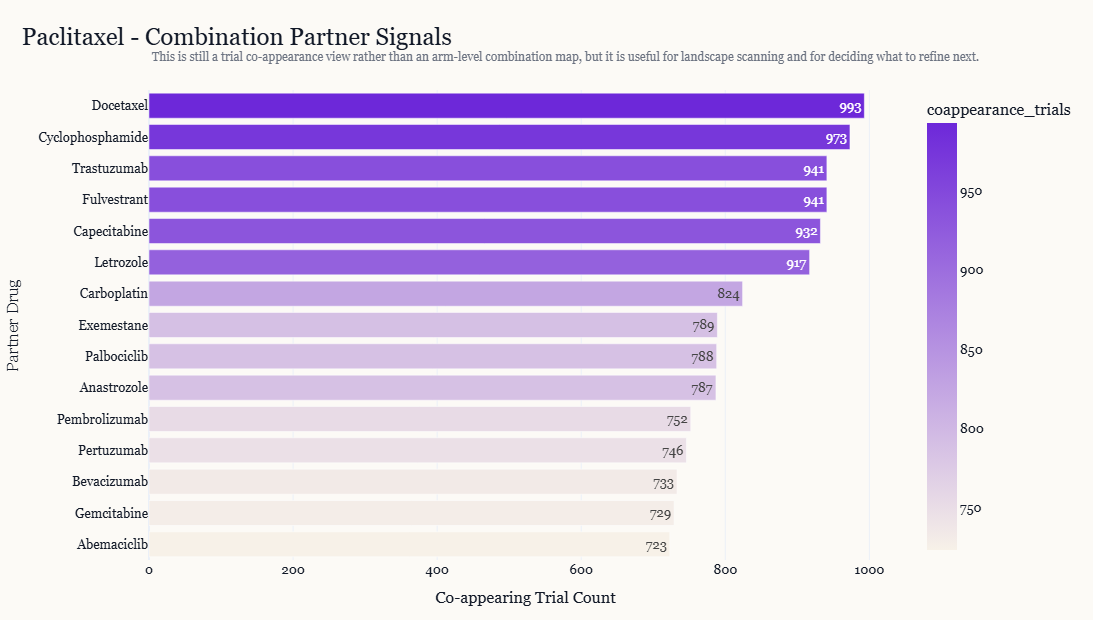

In [88]:
if partner_df.empty:
    print("No partner data available for the selected drug.")
else:
    fig_partners = px.bar(
        partner_df,
        x="coappearance_trials",
        y="partner_drug",
        orientation="h",
        color="coappearance_trials",
        color_continuous_scale=[PALETTE["sand"], PALETTE["violet"]],
        text="coappearance_trials",
    )
    pretty_layout(
        fig_partners,
        title=f"{SELECTED_DRUG} - Combination Partner Signals",
        subtitle="This is still a trial co-appearance view rather than an arm-level combination map, but it is useful for landscape scanning and for deciding what to refine next.",
        height=620,
    )
    fig_partners.update_yaxes(categoryorder="total ascending", title_text="Partner Drug")
    fig_partners.update_xaxes(title_text="Co-appearing Trial Count")
    fig_partners.show()

## 8. Presentation-ready Insight Table

In [89]:
insight_table = phase_summary.copy()
insight_table["trial_to_drug_ratio"] = np.where(
    insight_table["distinct_drugs"] > 0,
    (insight_table["unique_trials"] / insight_table["distinct_drugs"]).round(2),
    np.nan,
)
insight_table["avg_enrollment_per_trial"] = np.where(
    insight_table["unique_trials"] > 0,
    (insight_table["total_enrollment"] / insight_table["unique_trials"]).round(1),
    np.nan,
)
insight_table["commentary"] = [
    "Earliest discovery / first-in-human pressure",
    "Safety-to-efficacy transition zone",
    "Proof-of-concept density usually peaks here",
    "Late-stage validation and attrition pressure",
    "Post-approval extension and real-world depth",
]
insight_table

,phase,unique_trials,distinct_drugs,total_enrollment,trial_to_drug_ratio,avg_enrollment_per_trial,commentary
0,Early Phase 1,232,192,18532,1.21,79.9,Earliest discovery / first-in-human pressure
1,Phase 1,2743,2263,215653,1.21,78.6,Safety-to-efficacy transition zone
2,Phase 2,4744,2916,637736,1.63,134.4,Proof-of-concept density usually peaks here
3,Phase 3,1572,1048,1392901,1.50,886.1,Late-stage validation and attrition pressure
4,Phase 4,346,282,570312,1.23,1648.3,Post-approval extension and real-world depth


## Notes for the Website Build

- Keep the **phase funnel** based on interventional trials only.
- Keep observational trials as contextual side content, not inside the main funnel.
- Use `drug_phase_map.csv` for request-time backend endpoints because it is much lighter than rebuilding everything from `trials_processed.csv`.
- Use `cancer_hierarchy_final.json` only after one small API-layer cleanup / allowlist step so weak labels do not leak into the dropdown.
- Treat combination partners as **trial co-appearance** until you explicitly upgrade that logic to arm-level combinations.
- These Plotly visuals are analysis-ready and presentation-friendly; later, the frontend can reinterpret the same metrics using ECharts for a more premium product surface.